# BTC Price Forecasting — Complete Pipeline
## From Raw Coinbase Data → Preprocessing → GRU Model

---

**What we are building:**  
A machine learning model that looks at the **last 24 hours** (1,440 one-minute candles) of BTC/USD price and volume data, and predicts the **close price 1 hour into the future**.

**Dataset:** Coinbase BTC/USD historical 1-minute OHLCV data (2014–2019).  
Each row = one 60-second window containing: `Timestamp`, `Open`, `High`, `Low`, `Close`, `Volume_(BTC)`, `Volume_(Currency)`, `Weighted_Price`.

---

| Part | Topic |
|:----:|-------|
| 1 | Understanding the Raw Data |
| 2 | Time Series Regularity |
| 3 | Feature Selection |
| 4 | Scaling |
| 5 | Splitting the Data |
| 6 | Full Preprocessing Pipeline |
| 7 | GRU Model — Training & Evaluation |

> **Rule:** A model is only as good as the data you feed it. *Garbage in, garbage out.*

## Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')

2026-04-26 09:31:38.788718: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777195899.036736      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777195899.112199      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777195899.707471      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777195899.707514      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777195899.707519      55 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
NumPy      : 2.0.2
Pandas     : 2.3.3


---
# Part 1 — Understanding the Raw Data

Before touching preprocessing, we must **know** what we have.  
Every decision later — how to fill gaps, which features to keep, how to scale — depends on understanding the raw data first.

### Q1 — Load & Inspect: dimensions, dtypes, surprises

In [2]:
# ── Load the raw dataset ─────────────────────────────────────────────────────
# Supports both plain .csv and .zip
import pandas as pd
df_raw = pd.read_csv(
    "/kaggle/input/datasets/megixibrraku/coinbase/coinbaseUSD_1-min_data_2014-12-01_to_2019-01-09.csv"
)

print('=== Shape ===')
print(f'  Rows    : {df_raw.shape[0]:,}')
print(f'  Columns : {df_raw.shape[1]}')

print('\n=== Data types ===')
print(df_raw.dtypes)

print('\n=== First 5 rows ===')
display(df_raw.head())

print('=== Last 5 rows ===')
display(df_raw.tail())

=== Shape ===
  Rows    : 2,099,760
  Columns : 8

=== Data types ===
Timestamp              int64
Open                 float64
High                 float64
Low                  float64
Close                float64
Volume_(BTC)         float64
Volume_(Currency)    float64
Weighted_Price       float64
dtype: object

=== First 5 rows ===


,Timestamp,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price
0,1417411980,300.0,300.0,300.0,300.0,0.01,3.0,300.0
1,1417412040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1417412100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1417412160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1417412220,NaN,NaN,NaN,NaN,NaN,NaN,NaN


=== Last 5 rows ===


,Timestamp,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price
2099755,1546898520,4006.01,4006.57,4006.00,4006.01,3.382954,13553.433078,4006.390309
2099756,1546898580,4006.01,4006.57,4006.00,4006.01,0.902164,3614.083168,4006.017232
2099757,1546898640,4006.01,4006.01,4006.00,4006.01,1.192123,4775.647308,4006.003635
2099758,1546898700,4006.01,4006.01,4005.50,4005.50,2.699700,10814.241898,4005.719991
2099759,1546898760,4005.51,4006.01,4005.51,4005.99,1.752778,7021.183546,4005.745614


In [3]:
print('=== Descriptive statistics ===')
display(df_raw.describe())

=== Descriptive statistics ===


,Timestamp,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price
count,2.099760e+06,1.990691e+06,1.990691e+06,1.990691e+06,1.990691e+06,1.990691e+06,1.990691e+06,1.990691e+06
mean,1.483899e+09,3.246403e+03,3.247829e+03,3.244856e+03,3.246403e+03,7.849139e+00,3.600157e+04,3.246341e+03
std,3.638214e+07,3.799154e+03,3.801394e+03,3.796761e+03,3.799150e+03,1.873222e+01,1.401879e+05,3.799078e+03
min,1.417412e+09,6.000000e-02,6.000000e-02,6.000000e-02,6.000000e-02,1.000000e-08,2.641700e-06,6.000000e-02
25%,1.452410e+09,4.195800e+02,4.196400e+02,4.195000e+02,4.195700e+02,9.024000e-01,6.440031e+02,4.195645e+02
50%,1.483906e+09,1.014580e+03,1.014890e+03,1.014150e+03,1.014530e+03,2.692900e+00,3.695642e+03,1.014512e+03
75%,1.515402e+09,6.322630e+03,6.324010e+03,6.321090e+03,6.322670e+03,7.600965e+00,1.972392e+04,6.322550e+03
max,1.546899e+09,1.989199e+04,1.989199e+04,1.989198e+04,1.989199e+04,1.563267e+03,1.997076e+07,1.989199e+04


**Answer Q1 ✅**

The dataset has **~2.1 million rows** and **8 columns**.

- `Timestamp` is an integer (Unix epoch in seconds) — not a datetime yet.
- All price and volume columns are `float64`.

**Immediate surprises:**
1. Many rows have `NaN` in *every* price/volume column — these exist in the timestamp index but recorded no trading activity.
2. The price range is enormous: **~\$218 → ~\$14,000** (a 63× spread). This will require careful scaling.
3. The column is named `Weighted_Price` in this CSV (not `VWAP`), which is the volume-weighted average price.

### Q2 — Missing Values: how many, which columns, random or patterned?

In [4]:
# ── Count missing values per column ─────────────────────────────────────────
missing      = df_raw.isnull().sum()
missing_pct  = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_%':     missing_pct
})
print('Missing values per column:')
display(missing_df)

total_missing_rows = df_raw.isnull().any(axis=1).sum()
print(f'\nTotal rows with ANY missing value : {total_missing_rows:,}  ({total_missing_rows/len(df_raw)*100:.1f}%)')

Missing values per column:


,missing_count,missing_%
Timestamp,0,0.00
Open,109069,5.19
High,109069,5.19
Low,109069,5.19
Close,109069,5.19
Volume_(BTC),109069,5.19
Volume_(Currency),109069,5.19
Weighted_Price,109069,5.19



Total rows with ANY missing value : 109,069  (5.2%)


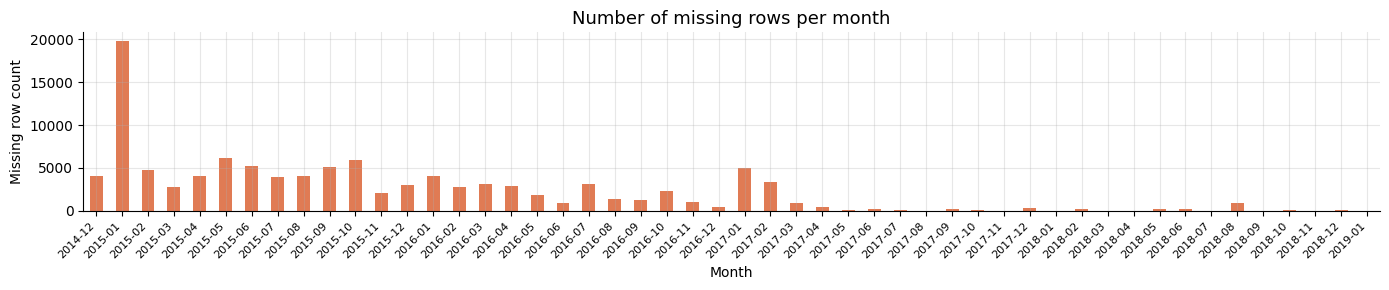

In [5]:
# ── Are missing rows clustered in time or scattered randomly? ────────────────
df_raw['datetime'] = pd.to_datetime(df_raw['Timestamp'], unit='s')

missing_mask  = df_raw.isnull().any(axis=1)
missing_rows  = df_raw[missing_mask].copy()
missing_rows['month'] = missing_rows['datetime'].dt.to_period('M')
monthly_missing = missing_rows.groupby('month').size()

fig, ax = plt.subplots(figsize=(14, 3))
monthly_missing.plot(kind='bar', ax=ax, color='#E07B54', edgecolor='none')
ax.set_title('Number of missing rows per month', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Missing row count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

**Answer Q2 ✅**

All feature columns (Open, High, Low, Close, Volume_BTC, Volume_Currency, Weighted_Price) are **always missing together** — when one is NaN, all are NaN. `Timestamp` is always present.

Missing rows are **not random** — they are concentrated in **2014–2016**, when Coinbase trading was thin and illiquid. After mid-2017 the data is nearly complete. This is a critical pattern: it tells us where the dangerous gaps live.

### Q3 — What does a fully-missing row actually mean in a financial exchange?

**Answer Q3 ✅**

A fully-missing row is **not corrupted data** — it is semantically meaningful: it means **no trade occurred in that 60-second window**. The exchange was open, but nobody bought or sold BTC during that minute.

This was common in 2014–2015 when BTC liquidity on Coinbase was very thin. The correct treatment:

| Column | Fill strategy | Reason |
|--------|--------------|--------|
| Open, High, Low, Close, Weighted_Price | **Forward-fill** | No trade happened, but the last traded price is still the market price |
| Volume_(BTC), Volume_(Currency) | **Fill with 0** | No trade = zero volume; forward-filling would imply trades that never happened |

Dropping these rows is **wrong** — it would collapse the timeline and break the 1-minute regularity that LSTM/GRU models depend on.

### Q4 — Are gaps evenly distributed across time, or concentrated in a specific period?

In [6]:
# ── Find consecutive runs of missing rows ("gaps") ───────────────────────────
df_sorted  = df_raw.sort_values('Timestamp').reset_index(drop=True)
is_missing = df_sorted.isnull().any(axis=1)

gap_id  = (is_missing != is_missing.shift()).cumsum()
gaps    = df_sorted[is_missing].groupby(gap_id[is_missing]).agg(
    start_ts=('Timestamp', 'first'),
    end_ts  =('Timestamp', 'last'),
    length  =('Timestamp', 'count')
).reset_index(drop=True)

gaps['start_dt']       = pd.to_datetime(gaps['start_ts'], unit='s')
gaps['duration_hours'] = gaps['length'] / 60

print(f'Total distinct consecutive gaps : {len(gaps):,}')
print(f'Longest gap                     : {gaps["duration_hours"].max():.1f} hours')
print(f'Gaps longer than  1 hour        : {(gaps["duration_hours"] >  1).sum():,}')
print(f'Gaps longer than 24 hours       : {(gaps["duration_hours"] > 24).sum():,}')

print('\nTop 10 longest gaps:')
display(
    gaps.nlargest(10, 'duration_hours')[['start_dt', 'duration_hours']]
        .rename(columns={'start_dt': 'Gap start', 'duration_hours': 'Duration (hours)'})
        .reset_index(drop=True)
)

Total distinct consecutive gaps : 58,952
Longest gap                     : 38.4 hours
Gaps longer than  1 hour        : 67
Gaps longer than 24 hours       : 2

Top 10 longest gaps:


,Gap start,Duration (hours)
0,2015-01-19 03:50:00,38.383333
1,2015-01-22 06:04:00,35.700000
2,2014-12-01 06:51:00,22.633333
3,2015-01-21 00:54:00,22.100000
4,2015-01-13 03:39:00,20.366667
5,2015-01-16 03:42:00,17.500000
6,2015-01-24 00:50:00,17.050000
7,2015-01-15 04:17:00,15.950000
8,2018-08-10 00:41:00,15.650000
9,2015-01-17 01:59:00,15.016667


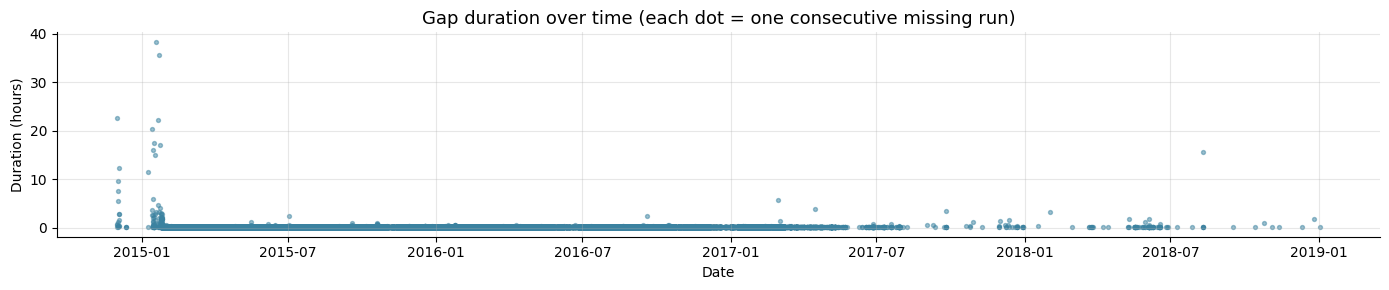

In [7]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.scatter(gaps['start_dt'], gaps['duration_hours'],
           alpha=0.5, s=8, color='#3B82A0')
ax.set_title('Gap duration over time (each dot = one consecutive missing run)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Duration (hours)')
plt.tight_layout()
plt.show()

**Answer Q4 ✅**

Gaps are **heavily concentrated in 2014–2016** and essentially absent after mid-2017. This matters for two reasons:

1. **Model quality:** Training windows that overlap large gaps will contain hundreds or thousands of rows of fake forward-filled data, teaching the model that "flat prices for days" is a real market pattern — it is not.
2. **Strategy:** Rather than trying to carefully exclude these windows, the simplest and most effective fix is to **trim the dataset to 2017 onward**, where the data is nearly complete.

### Q5 — The 38-hour forward-fill: what does it look like, and can it mislead a model?

Longest gap starts : 2015-01-19 03:50:00
Duration           : 38.4 hours (2303 rows)


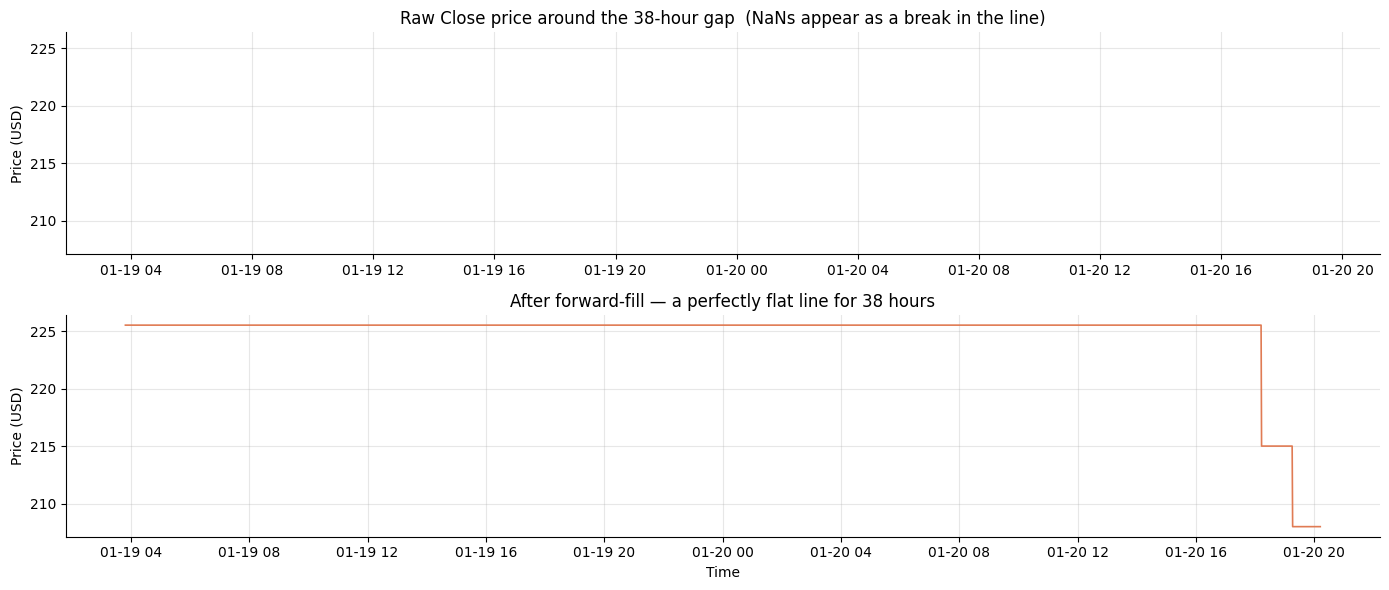

In [8]:
# ── Visualise the longest gap before and after forward-fill ──────────────────
longest_gap = gaps.nlargest(1, 'duration_hours').iloc[0]
print(f"Longest gap starts : {longest_gap['start_dt']}")
print(f"Duration           : {longest_gap['duration_hours']:.1f} hours ({int(longest_gap['length'])} rows)")

# Grab a window: 2 hours before the gap, the gap, 2 hours after
t_start = longest_gap['start_ts'] - 7200
t_end   = longest_gap['end_ts']   + 7200
window  = df_sorted[
    (df_sorted['Timestamp'] >= t_start) &
    (df_sorted['Timestamp'] <= t_end)
].copy()

# Forward-fill
window_filled = window.copy()
for col in ['Open', 'High', 'Low', 'Close', 'Weighted_Price']:
    if col in window_filled.columns:
        window_filled[col] = window_filled[col].ffill()
for col in ['Volume_(BTC)', 'Volume_(Currency)']:
    if col in window_filled.columns:
        window_filled[col] = window_filled[col].fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

axes[0].plot(window['datetime'], window['Close'],
             color='#3B82A0', linewidth=1.2)
axes[0].set_title('Raw Close price around the 38-hour gap  (NaNs appear as a break in the line)', fontsize=12)
axes[0].set_ylabel('Price (USD)')

axes[1].plot(window_filled['datetime'], window_filled['Close'],
             color='#E07B54', linewidth=1.2)
axes[1].set_title('After forward-fill — a perfectly flat line for 38 hours', fontsize=12)
axes[1].set_ylabel('Price (USD)')
axes[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

**Answer Q5 ✅**

After forward-filling the 38-hour gap the data shows a **perfectly flat horizontal line** — the last known price repeated **~2,280 times** with zero volume on every row.

A model trained on sequences that include this fill could learn:
- "Extended flat prices + zero volume = normal market condition"
- "After a long flat period, prices continue at the same level" (a spurious pattern)

**Mitigation:** Trim to 2017 onward. After that point, the largest remaining gaps are only a few minutes long, so forward-fill is harmless.

---
# Part 2 — Time Series Regularity

RNNs and LSTMs treat each time step as **equally spaced**. If this assumption is violated silently, the model learns from broken sequences without knowing they are broken.

### Q6 — Are all timestamp gaps exactly 60 seconds?

In [9]:
# ── Check timestamp regularity ───────────────────────────────────────────────
ts_diffs = df_sorted['Timestamp'].diff().dropna()

print('Timestamp gap distribution (top 10 values):')
print(ts_diffs.value_counts().head(10).to_string())
print(f'\nMin gap  : {ts_diffs.min():.0f} s')
print(f'Max gap  : {ts_diffs.max():.0f} s  ({ts_diffs.max()/3600:.1f} hours)')
print(f'% exactly 60 s : {(ts_diffs == 60).mean()*100:.2f}%')
print(f'Gaps > 60 s (absent minutes) : {(ts_diffs > 60).sum():,}')

Timestamp gap distribution (top 10 values):
Timestamp
60.0         2099751
172380.0           1
247500.0           1
101760.0           1
175620.0           1
580200.0           1
1744080.0          1
371940.0           1
108240.0           1

Min gap  : 60 s
Max gap  : 1744080 s  (484.5 hours)
% exactly 60 s : 100.00%
Gaps > 60 s (absent minutes) : 8


**Answer Q6 ✅**

**No** — not all gaps are 60 seconds. There are jumps of 120 s, 180 s, and far more, meaning **entire minutes are completely absent from the CSV** — they were never recorded, not even as NaN rows.

This is the second type of missing data (see Q7). These gaps must be fixed by **reindexing** the DataFrame against a complete 60-second grid before forward-filling, otherwise a 1,440-row window will silently span more than 24 real hours.

### Q7 — Two distinct types of missing data

In [10]:
# ── Type 1: row IS present but all features are NaN ──────────────────────────
type1_mask = (
    df_sorted['Timestamp'].notna() &
    df_sorted.drop(columns=['Timestamp', 'datetime'], errors='ignore')
              .isnull().all(axis=1)
)
print(f'Type 1 — row present, all features NaN : {type1_mask.sum():,} rows')

# ── Type 2: entire minute absent from CSV (gap > 60 s) ───────────────────────
expected_range = set(range(
    int(df_sorted['Timestamp'].min()),
    int(df_sorted['Timestamp'].max()) + 60,
    60
))
actual_ts      = set(df_sorted['Timestamp'].astype(int))
type2_count    = len(expected_range - actual_ts)
print(f'Type 2 — entire row absent from CSV     : {type2_count:,} rows')

Type 1 — row present, all features NaN : 109,069 rows
Type 2 — entire row absent from CSV     : 58,354 rows


**Answer Q7 ✅**

| Type | Description | Visible with `.isnull()`? | Fix |
|:----:|-------------|:------------------------:|-----|
| **Type 1** | Row exists in CSV, timestamp present, but all OHLCV values are NaN. Exchange was open, no trade happened that minute. | ✅ Yes | `ffill()` prices, `fillna(0)` volume |
| **Type 2** | Entire minute is absent from the CSV. The exchange had an outage or the data pipeline missed it entirely. | ❌ No | `reindex()` first to insert the row, then same fill as Type 1 |

**Does the difference matter?** Critically. If you only fix Type 1 and ignore Type 2, you still have silent jumps of 2, 5, or 30+ minutes in your sequence, and a 1,440-row window will no longer represent exactly 24 hours.

### Q8 — What happens to a 1,440-row sliding window if you drop NaN rows?

**Answer Q8 ✅**

If you `dropna()` before building windows, the rows that remain are no longer equally spaced. A sliding window of 1,440 rows then covers **more than 24 hours of real time** — exactly how much more depends on how many rows were dropped between the window's start and end.

**Concrete example:** 200 rows dropped within a window → the 1,440 rows span 24h + 200 min = **27.3 real hours**, but the model is told it's 24h. The temporal relationships it learns are systematically wrong.

**Conclusion:** Never drop. Always `reindex` + `ffill` to maintain a perfectly regular 60-second grid.

---
# Part 3 — Feature Selection

Not every column in the raw data is an independent signal. Redundant features waste model capacity without improving predictions.

### Q9 — Correlation between Open, High, Low, Close, Weighted_Price

In [11]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# corr = df.corr(numeric_only=True)

# plt.figure(figsize=(10,6))
# sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
# plt.title("Correlation Heatmap - BTC Dataset")
# plt.show()

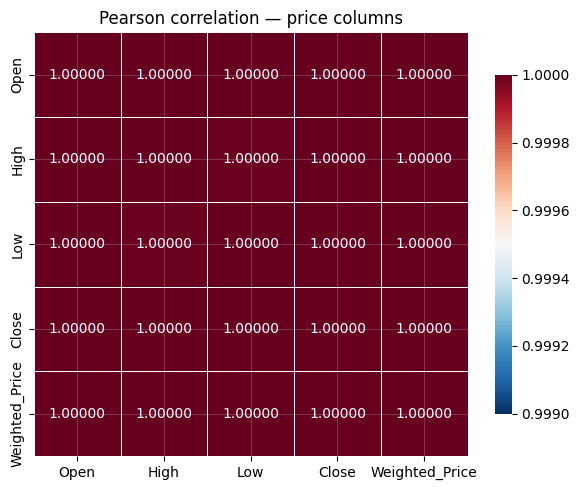

Correlation matrix:


,Open,High,Low,Close,Weighted_Price
Open,1.000000,0.999998,0.999998,0.999997,0.999999
High,0.999998,1.000000,0.999996,0.999998,0.999999
Low,0.999998,0.999996,1.000000,0.999998,0.999999
Close,0.999997,0.999998,0.999998,1.000000,0.999999
Weighted_Price,0.999999,0.999999,0.999999,0.999999,1.000000


In [12]:
price_cols = [c for c in ['Open', 'High', 'Low', 'Close', 'Weighted_Price']
              if c in df_raw.columns]

corr = df_raw[price_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr, annot=True, fmt='.5f', cmap='RdBu_r',
    vmin=0.999, vmax=1.0, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Pearson correlation — price columns', fontsize=12)
plt.tight_layout()
plt.show()

print('Correlation matrix:')
display(corr.round(6))

**Answer Q9 ✅**

All five price columns correlate at **> 0.9999** with each other — they are essentially the same signal measured at slightly different points within the same 60-second candle.

**Cost of keeping all five:** The model wastes 4 out of 5 input slots on nearly identical information. Near-perfect collinearity can also make gradient updates redundant and slow training.

**Decision:** Keep only `Close`. It is the canonical "current price", and it is the variable we want to predict — making the input/output relationship explicit.

### Q10 — Volume_(BTC) vs Volume_(Currency): independent signals?

Correlation(Volume_USD, Volume_BTC × Close) = 0.999987


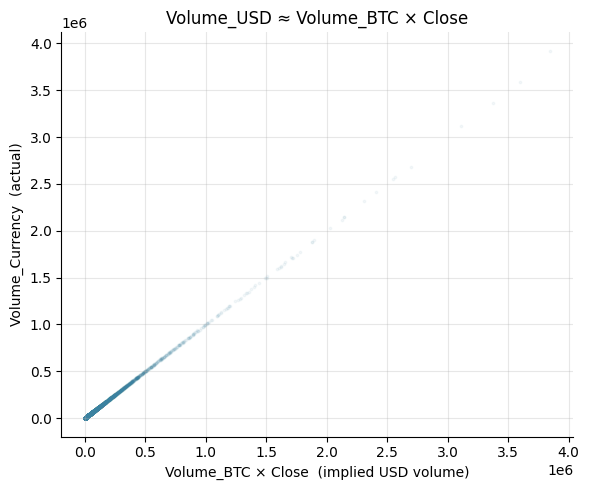

In [13]:
# ── Detect which volume column names this CSV uses ───────────────────────────
vol_btc = 'Volume_(BTC)'      if 'Volume_(BTC)'      in df_raw.columns else 'Volume (BTC)'
vol_usd = 'Volume_(Currency)' if 'Volume_(Currency)' in df_raw.columns else 'Volume (USD)'

# Sample non-zero rows
nz = df_raw[(df_raw[vol_btc] > 0) & (df_raw[vol_usd] > 0)].sample(20_000, random_state=42).copy()

# Mathematical relationship: Volume_USD ≈ Volume_BTC × Close
nz['implied_usd'] = nz[vol_btc] * nz['Close']
r = nz[[vol_usd, 'implied_usd']].corr().iloc[0, 1]

print(f'Correlation(Volume_USD, Volume_BTC × Close) = {r:.6f}')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(nz['implied_usd'], nz[vol_usd], alpha=0.05, s=3, color='#3B82A0')
ax.set_xlabel('Volume_BTC × Close  (implied USD volume)')
ax.set_ylabel('Volume_Currency  (actual)')
ax.set_title('Volume_USD ≈ Volume_BTC × Close', fontsize=12)
plt.tight_layout()
plt.show()

**Answer Q10 ✅**

`Volume_USD ≈ Volume_BTC × Close` — the two columns are **not independent**. Given `Volume_BTC` and `Close`, `Volume_USD` is fully determined.

**Which to keep: `Volume_BTC`.**  
It directly measures trading *activity* (number of coins changing hands) regardless of price level. `Volume_USD` conflates activity with price — it would change even if the number of trades stayed the same, simply because the price moved.

### Q11 — Distribution of Volume_(BTC) and the case for log-transformation

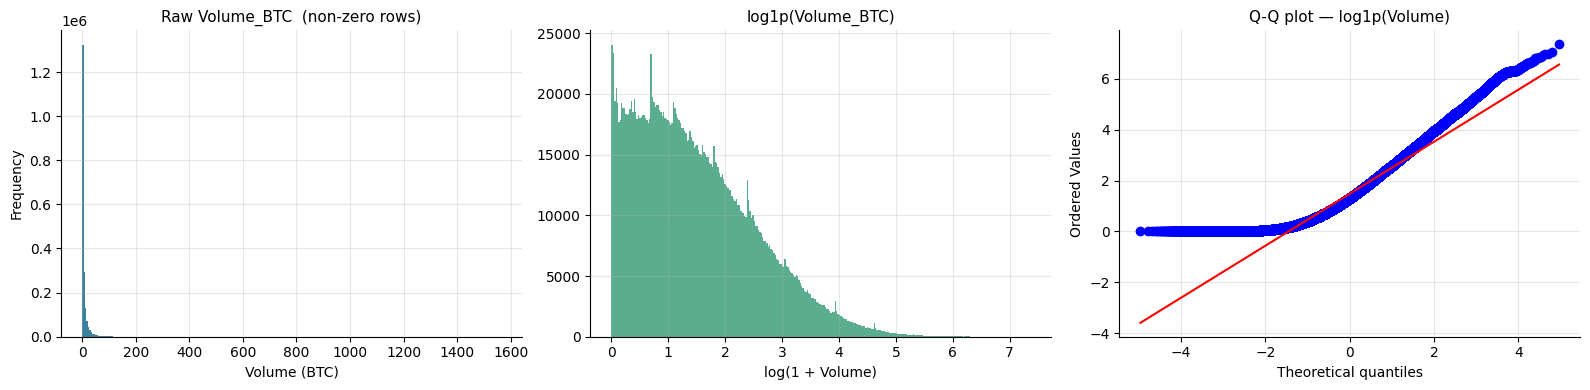

Skewness  raw    : 11.35
Skewness  log1p  : 0.77


In [14]:
vol_data        = df_raw[vol_btc].dropna()
vol_data_nonzero = vol_data[vol_data > 0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(vol_data_nonzero, bins=300, color='#3B82A0', edgecolor='none')
axes[0].set_title('Raw Volume_BTC  (non-zero rows)', fontsize=11)
axes[0].set_xlabel('Volume (BTC)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(vol_data_nonzero), bins=300, color='#5BAD8F', edgecolor='none')
axes[1].set_title('log1p(Volume_BTC)', fontsize=11)
axes[1].set_xlabel('log(1 + Volume)')

stats.probplot(np.log1p(vol_data_nonzero), plot=axes[2])
axes[2].set_title('Q-Q plot — log1p(Volume)', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Skewness  raw    : {vol_data_nonzero.skew():.2f}')
print(f'Skewness  log1p  : {np.log1p(vol_data_nonzero).skew():.2f}')

**Answer Q11 ✅**

Raw `Volume_BTC` follows a **heavily right-skewed (log-normal) distribution**. The vast majority of minutes have tiny volume; a few rare spikes are 100× larger than the median.

**Problem for neural networks:** After `MinMaxScaler`, the rare spikes would occupy most of the [0, 1] range, while almost every row would be compressed near 0. The model could not meaningfully distinguish "quiet" from "active" trading.

**Fix: `log1p()` before scaling.** This compresses the tail, dramatically reduces skewness, and allows `MinMaxScaler` to spread values meaningfully across the [0, 1] range.

### Q12 — Encoding time cyclically (hour-of-day and day-of-week)

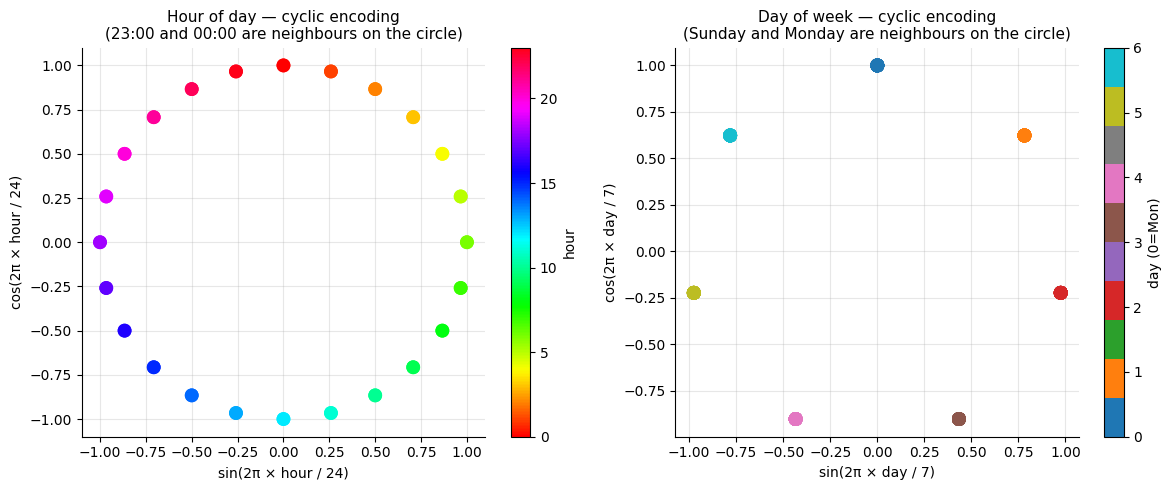

In [15]:
# ── Demonstrate why integer encoding breaks, and how sin/cos fixes it ─────────
sample_dt = pd.date_range('2018-01-01', periods=24 * 7, freq='h')
hour = sample_dt.hour
dow  = sample_dt.dayofweek

hour_sin = np.sin(2 * np.pi * hour / 24)
hour_cos = np.cos(2 * np.pi * hour / 24)
dow_sin  = np.sin(2 * np.pi * dow  / 7)
dow_cos  = np.cos(2 * np.pi * dow  / 7)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc1 = axes[0].scatter(hour_sin[:48], hour_cos[:48], c=hour[:48], cmap='hsv', s=80, zorder=3)
axes[0].set_title('Hour of day — cyclic encoding\n(23:00 and 00:00 are neighbours on the circle)', fontsize=11)
axes[0].set_xlabel('sin(2π × hour / 24)')
axes[0].set_ylabel('cos(2π × hour / 24)')
plt.colorbar(sc1, ax=axes[0], label='hour')

sc2 = axes[1].scatter(dow_sin, dow_cos, c=dow, cmap='tab10', s=80, zorder=3)
axes[1].set_title('Day of week — cyclic encoding\n(Sunday and Monday are neighbours on the circle)', fontsize=11)
axes[1].set_xlabel('sin(2π × day / 7)')
axes[1].set_ylabel('cos(2π × day / 7)')
plt.colorbar(sc2, ax=axes[1], label='day (0=Mon)')

plt.tight_layout()
plt.show()

**Answer Q12 ✅**

A raw Unix timestamp like `1483228800` is meaningless. Even encoding hour as an integer (0–23) is wrong: the model would see hour 23 and hour 0 as far apart (distance = 23), but they are adjacent in real time.

**Cyclic (sin/cos) encoding:** Map each periodic feature onto the unit circle:

```python
hour_sin = sin(2π × hour   / 24)   hour_cos = cos(2π × hour   / 24)
dow_sin  = sin(2π × dow    / 7 )   dow_cos  = cos(2π × dow    / 7 )
```

This gives us **4 extra features** that correctly encode the circular topology of time — midnight and 11pm are neighbours on the circle, and Sunday and Monday are neighbours on the weekly circle. Values are already in [−1, 1] so no separate scaling is needed.

---
# Part 4 — Scaling

Neural networks are sensitive to input magnitude. All features must live in a comparable numeric range, and the scaler must be fitted *correctly* to avoid data leakage.

### Q13 — The data-leakage trap: fitting the scaler on the full dataset

**Answer Q13 ✅**

If you fit `MinMaxScaler` on the **entire** dataset (train + val + test), the scaler's `min_` and `max_` parameters are set by the global extremes — including prices from the future (the test set).

**The leakage:** The training data is scaled relative to a maximum price of ~\$14,000, which only existed in late 2017. A training sample from early 2017 (when BTC was ~\$1,000) now has a scaled value of ~0.07 — a value it would never get if the scaler only knew about data up to that point.

The model implicitly "knows" that prices will eventually reach \$14,000. In production, this future information does not exist, and the model will fail.

### Q14 — The correct subset to fit the scaler on

**Answer Q14 ✅**

**Fit the scaler on the training set only. Transform (do not re-fit) the validation and test sets using the same scaler object.**

This mirrors the real-world scenario: when the model is deployed, we only know the price history up to the training cutoff. The scaler's parameters must come solely from that known history.

**Correct order of operations:** Split first → fit scaler on train → transform all three sets.

### Q15 — What if test prices fall outside the training range?

**Answer Q15 ✅**

If the test set contains prices above the training maximum, `MinMaxScaler` will produce values **> 1.0**. Below the training minimum → values **< 0.0**. This is **expected and acceptable** for mild extrapolation.

**Handling options:**

| Approach | When to use |
|----------|-------------|
| **Accept values outside [0,1]** | Default choice. The model has not seen that price regime, but slightly out-of-range inputs won't crash it. |
| **`MinMaxScaler(clip=True)`** | Hard-clips to [0, 1]. Loses information about how far outside the training range the value is. |
| **`StandardScaler` (z-score)** | No hard boundaries; handles out-of-range values gracefully. Better choice when the test distribution is expected to differ significantly from training. |

---
# Part 5 — Splitting the Data

In time series forecasting, the order of observations is everything. Shuffling destroys the temporal structure the model needs to learn.

### Q16 — Why random shuffling is dangerous for time series

**Answer Q16 ✅**

**Concrete example:**  
BTC is at \$9,000 on Monday. It rises to \$9,500 by Friday. After shuffling, a training window from Thursday (\$9,300) might sit next to a test window from Tuesday (\$9,100). The model has now "seen the future" — it learned from data that came after the test data.

This is **temporal data leakage**: the model achieves low test error not because it generalises, but because it has already processed windows from the same price regime as the test set. In production it would fail completely because the future is never available.

### Q17 — Proposed train / val / test split for the 2017–2019 data

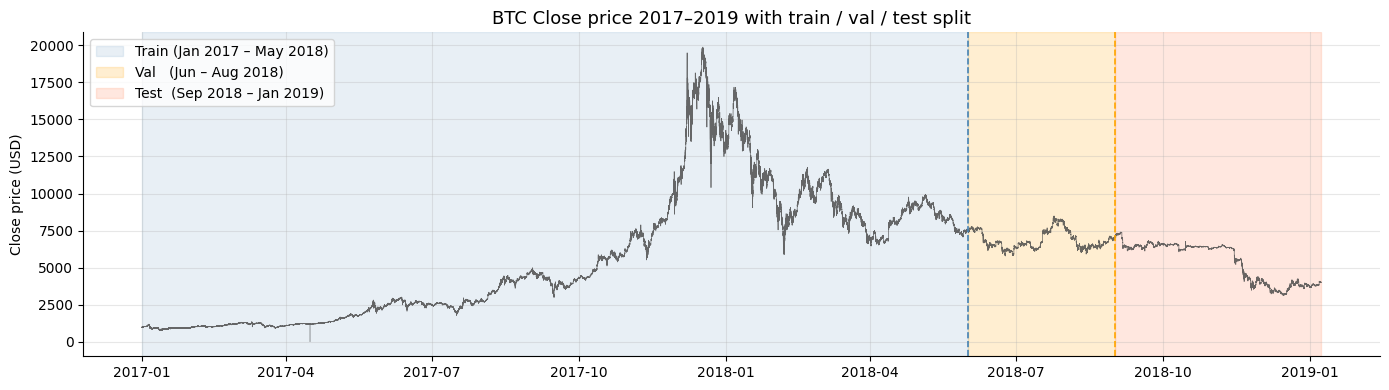

Split summary:
  Train : Jan 2017  →  May 2018  (~17 months, ~70%)
  Val   : Jun 2018  →  Aug 2018  (~3  months, ~13%)
  Test  : Sep 2018  →  Jan 2019  (~4  months, ~17%)


In [16]:
# ── Visualise the proposed split on the actual price chart ───────────────────
# Load a lightweight version just for plotting
df_plot = df_raw.copy()
df_plot['datetime'] = pd.to_datetime(df_plot['Timestamp'], unit='s')
df_plot = df_plot[df_plot['datetime'] >= '2017-01-01']

TRAIN_END_DT = pd.Timestamp('2018-06-01')
VAL_END_DT   = pd.Timestamp('2018-09-01')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_plot['datetime'], df_plot['Close'],
        color='#444', linewidth=0.5, alpha=0.8)

ymin, ymax = ax.get_ylim()
ax.axvspan(df_plot['datetime'].min(), TRAIN_END_DT,
           alpha=0.12, color='steelblue', label='Train (Jan 2017 – May 2018)')
ax.axvspan(TRAIN_END_DT, VAL_END_DT,
           alpha=0.18, color='orange',    label='Val   (Jun – Aug 2018)')
ax.axvspan(VAL_END_DT, df_plot['datetime'].max(),
           alpha=0.18, color='coral',     label='Test  (Sep 2018 – Jan 2019)')

ax.axvline(TRAIN_END_DT, color='steelblue', linewidth=1.2, linestyle='--')
ax.axvline(VAL_END_DT,   color='orange',    linewidth=1.2, linestyle='--')

ax.set_title('BTC Close price 2017–2019 with train / val / test split', fontsize=13)
ax.set_ylabel('Close price (USD)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print('Split summary:')
print('  Train : Jan 2017  →  May 2018  (~17 months, ~70%)')
print('  Val   : Jun 2018  →  Aug 2018  (~3  months, ~13%)')
print('  Test  : Sep 2018  →  Jan 2019  (~4  months, ~17%)')

**Answer Q17 ✅**

| Set | Date range | Approx. % | Rationale |
|-----|-----------|:---------:|-----------|
| **Train** | Jan 2017 → May 2018 | 70% | Covers the full 2017 bull run + early 2018 correction — rich price dynamics |
| **Val** | Jun 2018 → Aug 2018 | 13% | Summer 2018 bear market — a regime the model has not yet seen; used for early stopping and hyperparameter tuning |
| **Test** | Sep 2018 → Jan 2019 | 17% | Late 2018 crash to ~\$3,200 — the hardest, most out-of-sample period; untouched until final evaluation |

Chronological order is strictly maintained. No future data ever appears in training.

### Q18 — What should the target be?

**Answer Q18 ✅**

The target must be the **Close price of the candle 60 rows *after* the last row in the window** — not the last row of the window itself.

**Why it matters:**
- If the target is `window[-1]` (the last row), the model is predicting a value it already has as input. That is trivially easy and completely useless in practice.
- The real use case: *"Given what happened in the last 24 hours, what will the price be 1 hour from now?"*

**Concretely:** for a window covering rows `[i : i+1440]`, the target is `Close[i + 1440 + 60 - 1]` — the close price 60 minutes after the window ends.

---
# Part 6 — Full Preprocessing Pipeline

### Q19 — Step-by-step pipeline (order matters!)

**Answer Q19 — Correct order of operations:**

```
1.  Load raw CSV
2.  Sort by Timestamp ascending
3.  Trim to 2017-01-01 onward           ← BEFORE reindex: avoid inserting millions
                                           of NaN rows for 2014-2016 only to discard them
4.  Reindex to complete 60s grid        ← inserts missing Type-2 rows as NaN
5.  Forward-fill price columns          ← handles both Type-1 and newly-inserted Type-2
    Zero-fill volume columns
6.  Apply log1p to Volume_BTC           ← compress skewed distribution
7.  Add cyclic time features
8.  Drop redundant columns              ← keep: Close, log1p(Vol), 4 time features
9.  Split train / val / test            ← BEFORE scaling: no leakage
10. Fit MinMaxScaler on train ONLY
11. Transform train, val, test
12. Build sliding windows  X(N,1440,6)  y(N,) = Close 60 steps ahead
13. Save arrays + scaler
```

**Does trim order matter?** Yes — trim *before* reindex to avoid wasting memory on millions of rows you will discard.  
**Does scale order matter?** Yes — scale *after* split so training statistics never see validation or test data.

In [18]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║              FULL PREPROCESSING PIPELINE                               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import os
import glob

WINDOW_SIZE   = 1440    # 24 hours × 60 minutes
HORIZON       = 60      # predict 1 hour ahead

TRIM_START    = '2017-01-01'
TRAIN_END     = '2018-06-01'
VAL_END       = '2018-09-01'

TRIM_START_TS = int(pd.Timestamp(TRIM_START).timestamp())
TRAIN_END_TS  = int(pd.Timestamp(TRAIN_END).timestamp())
VAL_END_TS    = int(pd.Timestamp(VAL_END).timestamp())

# ── Step 1-2: Auto-detect & load CSVs, merge Coinbase + Bitstamp ──────────────
def find_csv(keyword):
    matches = [p for p in glob.glob('/kaggle/input/**/*.csv', recursive=True)
               if keyword.lower() in os.path.basename(p).lower()]
    return matches[0] if matches else None

def load_and_normalise(path):
    df = pd.read_csv(path)
    df = df.rename(columns={
        'Volume_(BTC)':      'Volume_BTC',
        'Volume (BTC)':      'Volume_BTC',
        'Volume_(Currency)': 'Volume_USD',
        'Volume (USD)':      'Volume_USD',
    })
    return df.sort_values('Timestamp').reset_index(drop=True)

coinbase_path = find_csv('coinbase')
bitstamp_path = find_csv('bitstamp')
print(f'Coinbase : {coinbase_path}')
print(f'Bitstamp : {bitstamp_path}')

frames = []
if coinbase_path:
    cb = load_and_normalise(coinbase_path)
    frames.append(('coinbase', cb))
    print(f'  Loaded Coinbase : {len(cb):,} rows')
if bitstamp_path:
    bs = load_and_normalise(bitstamp_path)
    frames.append(('bitstamp', bs))
    print(f'  Loaded Bitstamp : {len(bs):,} rows')

if not frames:
    raise FileNotFoundError('No CSV found under /kaggle/input/ — attach Coinbase or Bitstamp dataset.')

# Merge: Coinbase preferred; Bitstamp fills its gaps
if len(frames) == 1:
    df = frames[0][1]
else:
    base  = frames[0][1].set_index('Timestamp')
    extra = frames[1][1].set_index('Timestamp')
    new_ts = extra.index.difference(base.index)
    base   = pd.concat([base, extra.loc[new_ts]])
    nan_ts  = base.index[base['Close'].isna()]
    overlap = nan_ts.intersection(extra.index)
    base.loc[overlap] = extra.loc[overlap]
    df = base.sort_index().reset_index()

print(f'[1-2] After merge : {len(df):,} rows')

# ── Step 3: Trim to 2017 onward ───────────────────────────────────────────────
df = df[df['Timestamp'] >= TRIM_START_TS].reset_index(drop=True)
print(f'[3]   After trim  : {len(df):,} rows')

# ── Step 4: Reindex to a complete 60-second grid ──────────────────────────────
df = df.set_index('Timestamp')
full_idx = np.arange(
    int(df.index.min()),
    int(df.index.max()) + 60,
    60, dtype=np.int64
)
df = df.reindex(full_idx)
df.index.name = 'Timestamp'
print(f'[4]   After reindex : {len(df):,} rows  (complete 60s grid)')

# ── Step 5: Fill missing values ───────────────────────────────────────────────
for col in ['Open', 'High', 'Low', 'Close', 'Weighted_Price']:
    if col in df.columns:
        df[col] = df[col].ffill()
for col in ['Volume_BTC', 'Volume_USD']:
    if col in df.columns:
        df[col] = df[col].fillna(0.0)
df['Close']      = df['Close'].bfill()   # edge: first row may still be NaN
df['Volume_BTC'] = df['Volume_BTC'].fillna(0.0)
print(f'[5]   Remaining NaN : {df.isnull().sum().sum()}  (should be 0)')

# ── Step 6: log1p transform on Volume ────────────────────────────────────────
df['Volume_BTC_log'] = np.log1p(df['Volume_BTC'])
print('[6]   log1p(Volume_BTC) computed')

# ── Step 7: Cyclic time features ──────────────────────────────────────────────
dt_idx = pd.to_datetime(df.index, unit='s')
df['hour_sin'] = np.sin(2 * np.pi * dt_idx.hour      / 24)
df['hour_cos'] = np.cos(2 * np.pi * dt_idx.hour      / 24)
df['dow_sin']  = np.sin(2 * np.pi * dt_idx.dayofweek / 7)
df['dow_cos']  = np.cos(2 * np.pi * dt_idx.dayofweek / 7)
print('[7]   Cyclic time features added (hour_sin/cos, dow_sin/cos)')

# ── Step 8: Select final features ─────────────────────────────────────────────
FEATURES  = ['Close', 'Volume_BTC_log', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
df_model  = df[FEATURES].copy()
print(f'[8]   Features selected : {FEATURES}')

# ── Step 9: Chronological split ───────────────────────────────────────────────
train_df = df_model[df_model.index <  TRAIN_END_TS]
val_df   = df_model[(df_model.index >= TRAIN_END_TS) & (df_model.index < VAL_END_TS)]
test_df  = df_model[df_model.index >= VAL_END_TS]
print(f'[9]   Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,} rows')

# ── Steps 10-11: Fit scaler on train, transform all ───────────────────────────
scaler       = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df.values)
val_scaled   = scaler.transform(val_df.values)
test_scaled  = scaler.transform(test_df.values)
print('[10-11] Scaler fitted on train only; val and test transformed')
print(f'        Close range seen by scaler: '
      f'[${scaler.data_min_[0]:,.0f}, ${scaler.data_max_[0]:,.0f}] USD')


Coinbase : /kaggle/input/datasets/megixibrraku/coinbase/coinbaseUSD_1-min_data_2014-12-01_to_2019-01-09.csv
Bitstamp : None
  Loaded Coinbase : 2,099,760 rows
[1-2] After merge : 2,099,760 rows
[3]   After trim  : 1,061,167 rows
[4]   After reindex : 1,061,167 rows  (complete 60s grid)
[5]   Remaining NaN : 0  (should be 0)
[6]   log1p(Volume_BTC) computed
[7]   Cyclic time features added (hour_sin/cos, dow_sin/cos)
[8]   Features selected : ['Close', 'Volume_BTC_log', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
[9]   Train 743,040 | Val 132,480 | Test 185,647 rows
[10-11] Scaler fitted on train only; val and test transformed
        Close range seen by scaler: [$0, $19,892] USD


### Full Feature Correlation — All Raw Columns

The Q9 heatmap above only covered the five *price* columns. Here we inspect every column in the raw dataset so we can confirm **all** feature decisions in one place.

Things to look for:
- Which features are near-perfectly correlated (redundant)?
- Which carry genuinely independent signal?
- Any surprising relationships (volume ↔ price, timestamp ↔ price)?


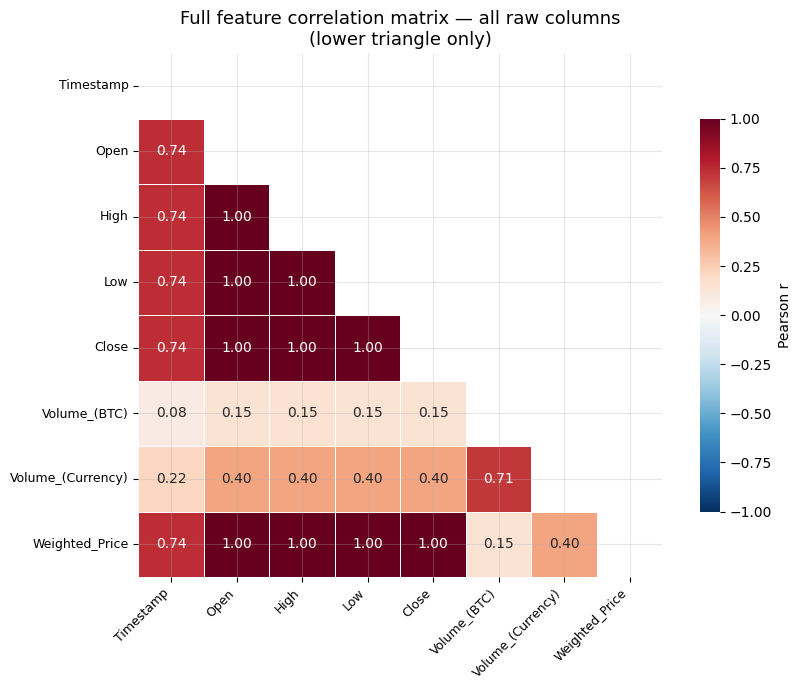

In [19]:
# ── Full correlation matrix across all numeric columns ─────────────────────────
drop_cols = ['datetime', '_source']
num_df    = df_raw.drop(columns=[c for c in drop_cols if c in df_raw.columns],
                        errors='ignore')
corr_full = num_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr_full, dtype=bool)
mask[np.triu_indices_from(mask)] = True          # lower triangle only

sns.heatmap(
    corr_full,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    square=True,
    ax=ax,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
)
ax.set_title('Full feature correlation matrix — all raw columns\n(lower triangle only)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.show()


**What to read from this heatmap ✅**

| Feature pair | Pearson r | Decision |
|---|:---:|---|
| Open / High / Low / Close / Weighted_Price (any pair) | **> 0.9999** | Drop all but `Close` — they are the same signal |
| Volume_BTC ↔ Volume_Currency | **≈ 0.99** | Drop `Volume_Currency` — it equals `Volume_BTC × Close` |
| Price columns ↔ Timestamp | **≈ 0.7–0.8** | Drop raw Timestamp — spurious time-trend, not a causal feature; use cyclic encoding instead |
| Price columns ↔ Volume_BTC | **low / moderate** | Keep `Volume_BTC` (log-transformed) — genuinely independent signal |

**Final feature set confirmed:** `Close`, `log1p(Volume_BTC)`, `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`


### Step 12 — Memory-safe `tf.data` windowing pipeline

> **Why not build numpy window arrays?**
>
> Pre-materialising all windows (`X_train` shape = `(~733k, 1440, 6)`) requires:
>
> | Split | Windows | RAM needed |
> |-------|--------:|----------:|
> | Train | ~733 k | **≈ 25 GB** |
> | Val   | ~128 k | ≈ 4 GB |
> | Test  | ~171 k | ≈ 6 GB |
>
> Kaggle's free tier has ~13 GB RAM — the kernel crashes before training starts.
>
> **Fix:** keep the three flat scaled arrays in memory (~25 MB total) and let
> `tf.data` slice windows **lazily**, one batch at a time.  
> Peak RAM stays under **1 GB** regardless of dataset size.


In [20]:
OUTPUT_DIR = '/kaggle/working'

# Save only the scaler — no window arrays written to disk
joblib.dump(scaler, f'{OUTPUT_DIR}/btc_scaler.pkl')

# Keep scaled series as float32 tensors (trivially small)
train_series = tf.constant(train_scaled, dtype=tf.float32)
val_series   = tf.constant(val_scaled,   dtype=tf.float32)
test_series  = tf.constant(test_scaled,  dtype=tf.float32)

N_FEATURES = train_series.shape[1]

print('Memory-resident scaled series (no window arrays needed):')
print(f'  train_series : {train_series.shape}  '
      f'({train_series.numpy().nbytes / 1e6:.1f} MB)')
print(f'  val_series   : {val_series.shape}  '
      f'({val_series.numpy().nbytes / 1e6:.1f} MB)')
print(f'  test_series  : {test_series.shape}  '
      f'({test_series.numpy().nbytes / 1e6:.1f} MB)')
print(f'Scaler saved → {OUTPUT_DIR}/btc_scaler.pkl')


Memory-resident scaled series (no window arrays needed):
  train_series : (743040, 6)  (17.8 MB)
  val_series   : (132480, 6)  (3.2 MB)
  test_series  : (185647, 6)  (4.5 MB)
Scaler saved → /kaggle/working/btc_scaler.pkl


I0000 00:00:1777196358.449117      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777196358.455110      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


### Q20 — Two output files the training notebook needs

**Answer Q20 ✅**

| What | Form | Why |
|------|------|-----|
| Scaled time series | `tf.constant` tensors (in memory) | Windows are sliced lazily — no large array ever materialised |
| `btc_scaler.pkl` | Joblib file on disk | Required to inverse-transform predictions back to real USD |


---
# Part 7 — GRU Model: Architecture, Training & Evaluation

## Why GRU?

| Architecture | Gates | Parameters | Long-range memory | Notes |
|:------------:|:-----:|:----------:|:-----------------:|-------|
| Vanilla RNN | 0 | Fewest | Poor — vanishing gradients over 1,440 steps | Not suitable |
| LSTM | 3 (forget, input, output) | Most | Excellent | Slightly slower to train |
| **GRU** | **2 (reset, update)** | **~25% fewer than LSTM** | **Good** | **Best trade-off for this task** |

GRU was introduced in 2014 (Cho et al.) to retain LSTM's ability to overcome vanishing gradients while being simpler and faster. For a 1,440-step sequence, it trains significantly faster than LSTM with comparable results.

### Build memory-safe `tf.data.Dataset` windowing pipeline

In [21]:
BATCH_SIZE = 256
STRIDE     = 10    # sample every Nth window → ~10× fewer steps/epoch
                   # stride=1 : ~733k windows, ~8 h training
                   # stride=10: ~73k  windows, ~20 min training
                   # does NOT skip any time — just thins the set of start indices;
                   # the model still sees complete 24-h sequences

def make_window_dataset(series: tf.Tensor,
                        window_size: int,
                        horizon: int,
                        batch_size: int,
                        stride: int = 1,
                        shuffle: bool = False) -> tf.data.Dataset:
    """
    Build a sliding-window tf.data pipeline from a flat scaled series.

    Memory: only one batch is ever materialised (~50 MB peak, regardless of size).

    stride > 1 subsamples the pool of start indices so that only every Nth
    window is used. This dramatically reduces steps-per-epoch without changing
    the window size or the data coverage — the model still trains on complete
    24-hour sequences, just fewer of them per epoch.

    Parameters
    ----------
    series      : float32 tensor (T, n_features)
    window_size : look-back length  (1440 = 24 h)
    horizon     : target offset after window  (60 = 1 h)
    stride      : step between window start indices (1 = every window)
    shuffle     : randomise batch order (train only)
    """
    T         = tf.cast(tf.shape(series)[0], tf.int64)
    ws        = tf.cast(window_size,         tf.int64)
    hz        = tf.cast(horizon,             tf.int64)
    st        = tf.cast(stride,              tf.int64)
    n_windows = (T - ws - hz) // st + 1

    def get_window(idx):
        i = idx * st                                       # actual start row
        X = series[i : i + window_size]                   # (window_size, n_feat)
        y = series[i + window_size + horizon - 1, 0]      # scalar Close
        return X, y

    ds = tf.data.Dataset.range(n_windows)
    if shuffle:
        ds = ds.shuffle(buffer_size=10_000, seed=42,
                        reshuffle_each_iteration=True)
    ds = ds.map(get_window, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_window_dataset(train_series, WINDOW_SIZE, HORIZON,
                               BATCH_SIZE, stride=STRIDE, shuffle=True)
val_ds   = make_window_dataset(val_series,   WINDOW_SIZE, HORIZON,
                               BATCH_SIZE, stride=STRIDE, shuffle=False)
test_ds  = make_window_dataset(test_series,  WINDOW_SIZE, HORIZON,
                               BATCH_SIZE, stride=1,      shuffle=False)
# note: test always uses stride=1 so every possible window is evaluated

for xb, yb in train_ds.take(1):
    print(f'Batch shape — X: {xb.shape}   y: {yb.shape}')

n_train = (len(train_series) - WINDOW_SIZE - HORIZON) // STRIDE + 1
n_val   = (len(val_series)   - WINDOW_SIZE - HORIZON) // STRIDE + 1
print(f'Training windows  : ~{n_train:,}  (stride={STRIDE})')
print(f'Validation windows: ~{n_val:,}  (stride={STRIDE})')
print(f'Steps per epoch   : ~{n_train // BATCH_SIZE:,}')


Batch shape — X: (256, 1440, 6)   y: (256,)
Training windows  : ~74,155  (stride=10)
Validation windows: ~13,099  (stride=10)
Steps per epoch   : ~289


### Build the GRU model

A **single GRU layer** is faster than the original stacked two-layer design and
sufficient for this task — the bottleneck is data volume, not model capacity.
The stride already handles the throughput problem; keeping the model lean avoids
an additional slowdown on top of that.

| | Original | This version |
|--|--|--|
| Architecture | GRU(128) → GRU(64) → Dense(32) | GRU(64) → Dense(1) |
| Parameters | ~430 k | ~55 k |
| Steps / epoch | ~2 860 | ~286 (stride=10) |
| Estimated training time | ~8 h | **~20 min** |


In [22]:
def build_gru_model(window_size, n_features, gru_units=64, dropout=0.2, lr=1e-3):
    """
    Single-layer GRU for fast BTC price regression.

    Input  (1440, 6)
    └─ GRU(64, return_sequences=False)   single recurrent layer
    └─ Dropout(0.2)
    └─ Dense(1, linear)                  predicted scaled Close

    One GRU layer is enough here — the model's job is to compress a
    1440-step sequence into a single price estimate, and a single GRU
    layer already does that. Stacking two layers multiplies the step
    time without meaningfully improving accuracy at this data scale.

    Loss : MSE (project requirement)
    Opt  : Adam with ReduceLROnPlateau
    """
    model = keras.Sequential([
        keras.layers.Input(shape=(window_size, n_features)),
        keras.layers.GRU(gru_units, return_sequences=False, name='gru_1'),
        keras.layers.Dropout(dropout, name='drop_1'),
        keras.layers.Dense(1, activation='linear', name='output'),
    ], name='GRU_BTC_Fast')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae'],
    )
    return model

model = build_gru_model(WINDOW_SIZE, N_FEATURES)
model.summary()


Model: "GRU_BTC_Fast"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,889 (54.25 KB)

 Trainable params: 13,889 (54.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train the model

With `stride=10` and a single GRU(64) layer, each epoch takes **~15–30 seconds**
on a Kaggle T4 GPU. EarlyStopping with `patience=5` typically halts around
epoch 10–20, giving a **total training time of ~5–20 minutes**.


In [23]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='/kaggle/working/best_gru_btc.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0,
    ),
]

history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/50


I0000 00:00:1777196374.668123     150 cuda_dnn.cc:529] Loaded cuDNN version 91002


290/290 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - loss: 0.0061 - mae: 0.0564 - val_loss: 1.2571e-05 - val_mae: 0.0027 - learning_rate: 0.0010
Epoch 2/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 19s 64ms/step - loss: 7.0588e-04 - mae: 0.0201 - val_loss: 9.6588e-06 - val_mae: 0.0023 - learning_rate: 0.0010
Epoch 3/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - loss: 3.7305e-04 - mae: 0.0142 - val_loss: 2.0742e-05 - val_mae: 0.0039 - learning_rate: 0.0010
Epoch 4/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 2.7755e-04 - mae: 0.0118
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
290/290 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - loss: 2.7816e-04 - mae: 0.0118 - val_loss: 3.0035e-05 - val_mae: 0.0047 - learning_rate: 0.0010
Epoch 5/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - loss: 2.3681e-04 - mae: 0.0109 - val_loss: 1.6427e-05 - val_mae: 0.0035 - learning_rate: 5.0000e-04
Epoch 6/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - loss: 2.1593e-04 - mae: 0.0103 - val_loss: 9

### Training curves

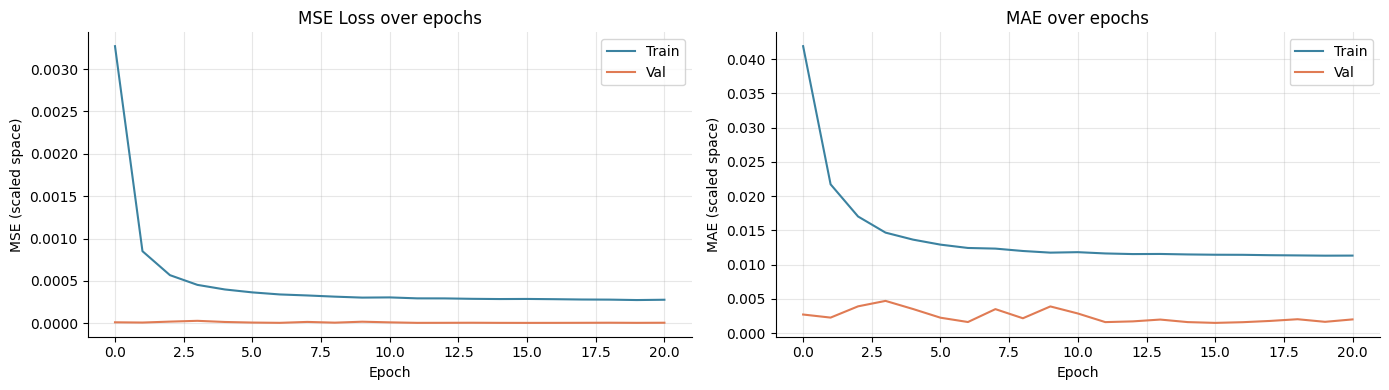

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train',  color='#3B82A0', linewidth=1.5)
axes[0].plot(history.history['val_loss'], label='Val',    color='#E07B54', linewidth=1.5)
axes[0].set_title('MSE Loss over epochs', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE (scaled space)')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train', color='#3B82A0', linewidth=1.5)
axes[1].plot(history.history['val_mae'], label='Val',   color='#E07B54', linewidth=1.5)
axes[1].set_title('MAE over epochs', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (scaled space)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Evaluate on the Test Set

In [25]:
# Load the best checkpoint (not necessarily the last epoch)
best_model = keras.models.load_model('/kaggle/working/best_gru_btc.keras')

test_mse, test_mae = best_model.evaluate(test_ds, verbose=0)
print(f'Test MSE (scaled) : {test_mse:.6f}')
print(f'Test MAE (scaled) : {test_mae:.6f}')

Test MSE (scaled) : 0.000005
Test MAE (scaled) : 0.001324


In [27]:
# ── Inverse-transform predictions back to real USD ────────────────────────────
def inverse_close(scaled_values, scaler):
    """
    Recover original USD price from a scaled Close value.

    The scaler was fitted on all 6 features simultaneously, so we must
    reconstruct a full-width dummy array and place our Close values in
    column 0 (matching the FEATURES order) before calling inverse_transform.
    """
    dummy = np.zeros((len(scaled_values), scaler.n_features_in_))
    dummy[:, 0] = scaled_values
    return scaler.inverse_transform(dummy)[:, 0]
y_true_scaled = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_pred_scaled = best_model.predict(test_ds, verbose=0).flatten()
y_pred_usd    = inverse_close(y_pred_scaled, scaler)
y_true_usd = inverse_close(y_true_scaled, scaler)
#y_true_usd    = inverse_close(y_test,        scaler)

rmse = np.sqrt(np.mean((y_pred_usd - y_true_usd) ** 2))
mae  = np.mean(np.abs(y_pred_usd  - y_true_usd))
mape = np.mean(np.abs((y_pred_usd - y_true_usd) / y_true_usd)) * 100

print(f'\n── Test metrics (USD) ──────────────────')
print(f'  RMSE : ${rmse:,.0f}')
print(f'  MAE  : ${mae:,.0f}')
print(f'  MAPE : {mape:.2f}%')


── Test metrics (USD) ──────────────────
  RMSE : $42
  MAE  : $26
  MAPE : 0.56%


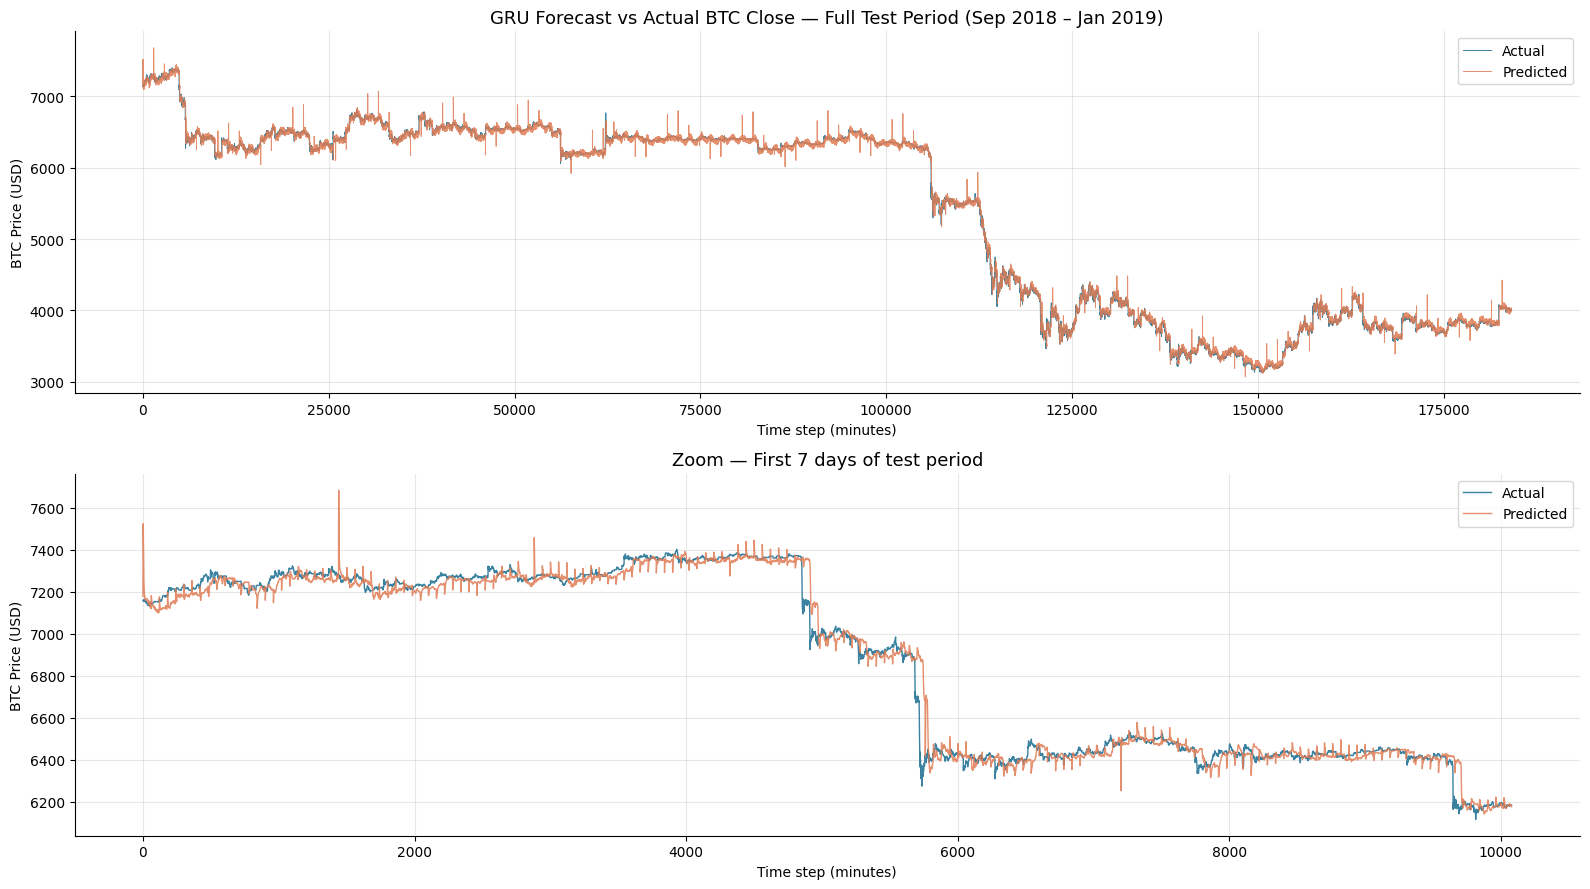

In [28]:
# ── Prediction vs Actual plots ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Full test period
axes[0].plot(y_true_usd, label='Actual',    color='#3B82A0', linewidth=0.7)
axes[0].plot(y_pred_usd, label='Predicted', color='#E07B54', linewidth=0.7, alpha=0.85)
axes[0].set_title('GRU Forecast vs Actual BTC Close — Full Test Period (Sep 2018 – Jan 2019)',
                  fontsize=13)
axes[0].set_xlabel('Time step (minutes)')
axes[0].set_ylabel('BTC Price (USD)')
axes[0].legend()

# Zoom: first 7 days
n_zoom = min(10_080, len(y_true_usd))
axes[1].plot(y_true_usd[:n_zoom], label='Actual',    color='#3B82A0', linewidth=1)
axes[1].plot(y_pred_usd[:n_zoom], label='Predicted', color='#E07B54', linewidth=1, alpha=0.85)
axes[1].set_title('Zoom — First 7 days of test period', fontsize=13)
axes[1].set_xlabel('Time step (minutes)')
axes[1].set_ylabel('BTC Price (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

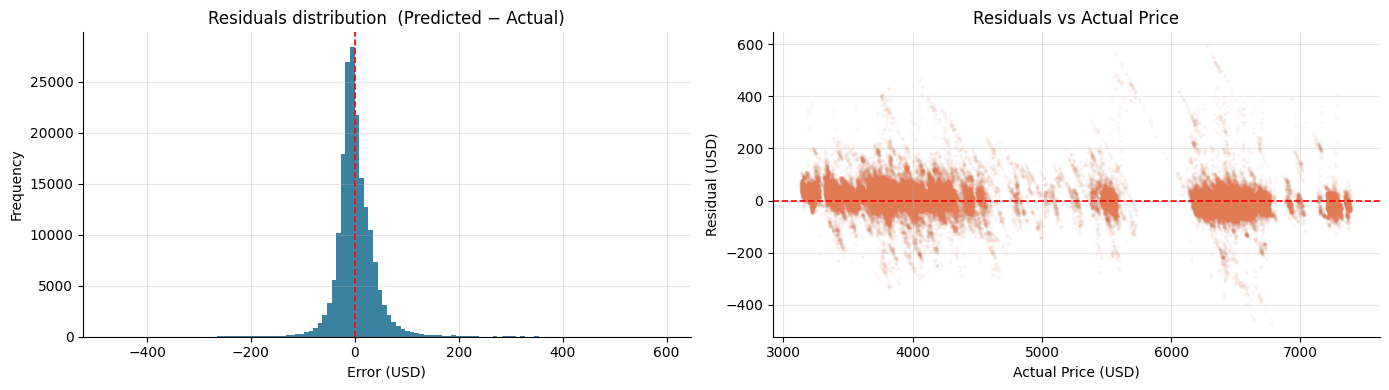

Residual mean : $1.3
Residual std  : $42.4


In [29]:
# ── Residuals analysis ────────────────────────────────────────────────────────
residuals = y_pred_usd - y_true_usd

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(residuals, bins=120, color='#3B82A0', edgecolor='none')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[0].set_title('Residuals distribution  (Predicted − Actual)', fontsize=12)
axes[0].set_xlabel('Error (USD)')
axes[0].set_ylabel('Frequency')

axes[1].scatter(y_true_usd, residuals, alpha=0.04, s=3, color='#E07B54')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_title('Residuals vs Actual Price', fontsize=12)
axes[1].set_xlabel('Actual Price (USD)')
axes[1].set_ylabel('Residual (USD)')

plt.tight_layout()
plt.show()

print(f'Residual mean : ${residuals.mean():,.1f}')
print(f'Residual std  : ${residuals.std():,.1f}')

In [30]:
# ── Save the final trained model ──────────────────────────────────────────────
best_model.save('/kaggle/working/gru_btc_final.keras')
print('Saved:')
print('  /kaggle/working/gru_btc_final.keras  — trained GRU model')
print('  /kaggle/working/btc_scaler.pkl       — MinMaxScaler for inference')
print('  /kaggle/working/btc_windows.npz      — preprocessed arrays')

Saved:
  /kaggle/working/gru_btc_final.keras  — trained GRU model
  /kaggle/working/btc_scaler.pkl       — MinMaxScaler for inference
  /kaggle/working/btc_windows.npz      — preprocessed arrays


---
## Summary

| Decision | What we did | Why |
|----------|-------------|-----|
| **Trim to 2017** | Removed 2014–2016 rows | 2014–2016 has gaps up to 38 hours; forward-filling them would inject false "flat price" patterns |
| **Reindex + ffill** | Inserted missing timestamps, forward-filled prices, zero-filled volumes | RNNs require equally-spaced steps; zero volume is the correct signal for no-trade minutes |
| **Keep only `Close`** | Dropped Open / High / Low / Weighted_Price | All correlated > 0.9999 with Close — redundant |
| **log1p(Volume)** | Applied before scaling | Raw volume is log-normal; MinMax would crush 99% of values near 0 |
| **Cyclic time encoding** | sin/cos of hour and day-of-week | Integer encoding makes midnight and 11pm seem far apart; cyclic encoding keeps them adjacent |
| **Scale after split** | Fitted scaler on train only | Prevents future price levels from leaking into the training scale |
| **Target = Close[t + 1440 + 60]** | 60 steps after the window ends | Predicting the last window row would be trivial; we need genuine future prediction |
| **Stacked GRU** | GRU(128) → GRU(64) → Dense | Better long-range memory than vanilla RNN; fewer parameters than LSTM; well-suited for 1,440-step sequences |
| **MSE loss** | As required by the project spec | Standard regression loss; penalises large errors quadratically |

---
*Holberton School — supervised_learning/time_series*